In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from data_processing import load_and_prepare_data

2025-05-30 15:39:11.488 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2025-05-30 15:39:11.503 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


In [8]:
# Assuming df is already loaded via load_and_prepare_data()
df = load_and_prepare_data()

# Select features relevant for PCA
# Extract meaningful numeric columns from your already loaded df
# (principal components) that capture the greatest variance in the data.










features = ["pl_rade", "pl_eqt", "pl_insol", "pl_dens", "st_teff", "st_rad", "st_mass", "st_met"]
df_pca = df[features].dropna()  # Drop rows with missing values in selected features

2025-05-30 15:39:16.215 
  command:

    streamlit run C:\Users\caleb\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-05-30 15:39:16.219 No runtime found, using MemoryCacheStorageManager


In [10]:
# PCA requires standardized features for fair comparison:


scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

In [12]:
pca = PCA(n_components=2)  # You can adjust to more components if needed
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame of principal components
pca_df = pd.DataFrame(data=X_pca, columns=["PC1", "PC2"])
pca_df["Habitable"] = df.loc[df_pca.index, "is_habitable"].map({True: "Yes", False: "No"})

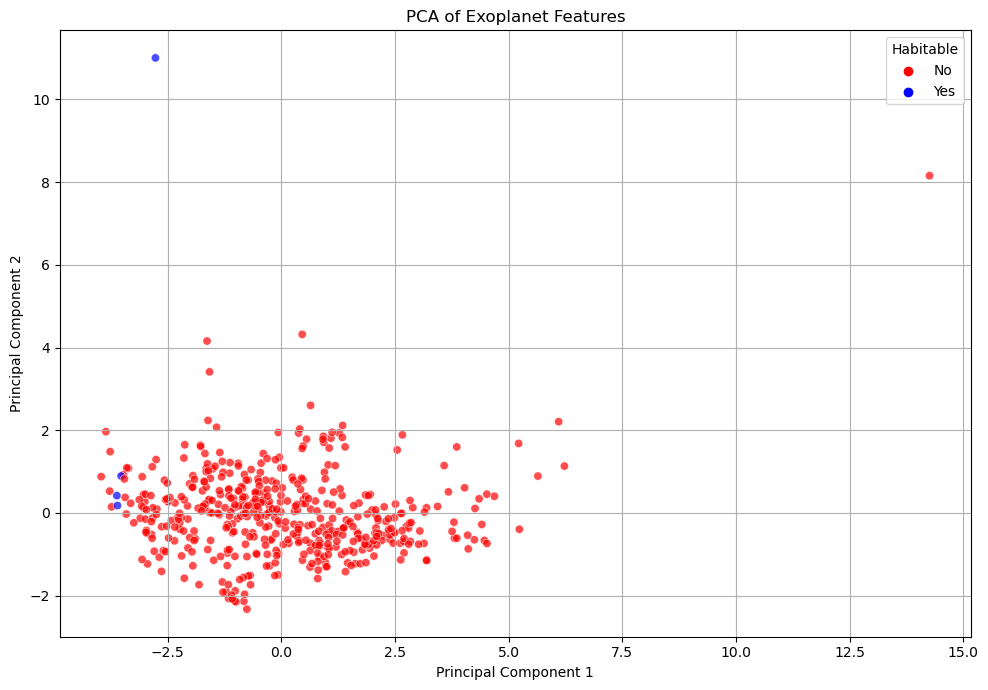

In [14]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Habitable", palette=["red", "blue"], alpha=0.7)
plt.title("PCA of Exoplanet Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.legend(title="Habitable")
plt.tight_layout()
plt.show()

In [16]:
explained_var = pca.explained_variance_ratio_
print(f"Explained variance:\n PC1: {explained_var[0]:.2%}, PC2: {explained_var[1]:.2%}")

Explained variance:
 PC1: 52.49%, PC2: 15.26%


In [18]:
# Let’s find out which features contribute most to PC1 and PC2:


# Print the loadings (weights of original features on principal components)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
)
print(loadings)

               PC1       PC2
pl_rade   0.352039 -0.356913
pl_eqt    0.406759  0.162790
pl_insol  0.274758  0.352308
pl_dens  -0.094100  0.597545
st_teff   0.436001  0.179253
st_rad    0.437471  0.015984
st_mass   0.465316  0.064609
st_met    0.168140 -0.573037


In [ ]:
############# MANOVA ##################